In [1]:
import sys
from dotenv import load_dotenv
import os
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.plotting.plotter_localization import PlotterLocalization

#load a test bench once created
from odometry.localization.particle_filter import particleFilter

In [2]:
#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")

#setup the datasets
#initial experiments: "/data/radnav/rad_nav_rotate_experiments/wilk_origin_forward/"

dataset = radnavDS(
    dataset_path=DATASET_PATH + "/WILK_BASEMENT_2",
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilk_basement.yaml"
)

#TODO move this to the test bench
plotter = PlotterLocalization(dataset,map_handler)

found 2063 radar samples
found 2063 lidar samples
found 2063 camera samples
found 2063 imu (orientation only) samples
found 2063imu (full data) samples
found 2063 vehicle velocity samples
loaded map from /data/radnav/maps/wilk_basement.yaml
loaded map free space from /data/radnav/maps/wilk_basement.yaml


In [3]:
#TODO: move to the test bench
particle_filter = particleFilter(max_particles=1000)

#load the map
particle_filter.load_map_point_cloud(map_handler.map_points)
particle_filter.load_map_free_points(map_handler.map_free_points)

loaded map with 16346 points

loaded map with 16346 free points



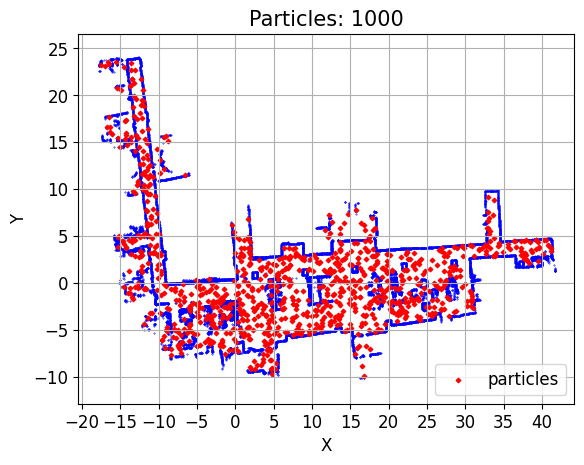

In [4]:
#initialize the particle filter with a uniform set of points
particle_filter.particles = particle_filter.get_uniform_particles_from_free_space(
    hdg_range=(0,2*np.pi),
    N=1000
)

#plot the particles
plotter.plot_particles_on_map(
    particles=particle_filter.particles,
    display_arrows=False,
    show=True
)

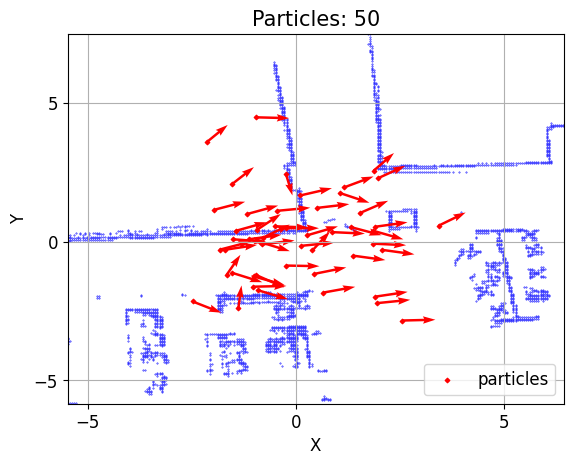

In [5]:
#get a distribution of particles using a gaussian
mean = np.array([0.0,0.0,0.0])
cov = np.zeros((3,3),dtype=float)
np.fill_diagonal(cov,[2.0,2.0,0.25])
particles = particle_filter.get_gaussian_particles(
    mean,
    cov,
    N=50
)

#plot the particles
plotter.plot_particles_on_map(
    particles=particles,
    display_arrows=True,
    show=True
)

In [8]:
def get_rot_matrix(rot_angle_rad):
    """Get a rotation matrix for a given rotation angle

    Args:
        rot_angle_rad (double): the desired rotation angle in radians

    Returns:
        np.ndarray: a 2x2 rotation matrix for the desired rotation
    """
    return np.array([
        [np.cos(rot_angle_rad), -1.0 * np.sin(rot_angle_rad)],
        [np.sin(rot_angle_rad), np.cos(rot_angle_rad)]
    ])

# def apply_rot_trans_multiple(
#             points:np.ndarray,
#             rot_angles_rad:np.ndarray,
#             translations:np.ndarray):
#         """Apply a rotation and translation to a set of points using
#         the formulat out = (points * R.T) + trans

#         Args:
#             points (np.ndarray): Nx2 array of points to be transformed
#             rot_angle_rad (_type_): the rotation angle in radians to rotate
#                 the points by
#             trans (_type_): the [x,y] translation vector to apply

#         Returns:
#             np.ndarray: An Nx2 array of the transformed points
#         """

#         # transform 'points' (using the calculated rotation and translation)
#         R = np.array([get_rot_matrix(rot_angle_rad) for \
#                       rot_angle_rad in rot_angles_rad])
        
#         exp
        
#         #apply the rotation matrix and translation
#         return (points @ R.T) + trans   

In [15]:
#single transformation method
detections = dataset.get_radar_detections(idx=0)

points = detections[:,0:2]
rot_angles_rad = particle_filter.particles[0,2]
translations = particle_filter.particles[0,0:2]

R = get_rot_matrix(rot_angles_rad)

out_1D = points @ R.transpose() + translations

In [29]:
#testing the measurement model computation time

#get a radar point cloud sample
detections = dataset.get_radar_detections(idx=0)

# updated_weights = particle_filter.liklihood_field_measurement_model(
#     particles=particle_filter.particles,
#     points=detections[:,:2]
# )
points = detections[:,0:2]
rot_angles_rad = particle_filter.particles[:,2]
translations = particle_filter.particles[:,0:2]

#compute the rotation matrix for each rotation
points_extended = points[np.newaxis,:,:]
R = np.array([get_rot_matrix(rot_angle_rad) for \
        rot_angle_rad in rot_angles_rad])

R_transposed = R.transpose((0,2,1))
translations_extended = translations[:,np.newaxis,:]

points_rotated = np.matmul(points_extended,R_transposed)

out_points = points_rotated + translations_extended

[-0.14230406 -0.02616242]
[3.175002 1.625002]
[3.03269794 1.59883958]
